In [1]:
# standard import packages
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns
import sklearn as skl
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')

In [2]:
# packaages for BNN analysis
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

***
# Uncertainty-aware customer churn model:
Here, we're going to analyze customer data from Telco, and study + predict customer-churn using a variety of ML models. With Logistic Regression, XGBoost, and ultimately a Bayesian Neural Network for uncertainty-encapsulation, we'll then present our findings. 

In [48]:
# Import customer data
teldf = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {teldf.shape}")
teldf.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
### Checking data types
teldf.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
### Unusual data type for Totalcharges, expecting dollar amount to be a float
print(teldf["TotalCharges"].dtype)

str


In [6]:
### If string data type, possibility of empty entries?
empties = teldf["TotalCharges"].astype(str).str.strip() == ""

In [7]:
### Indices where TotalCharges entry is empty
np.where(empties == True)

(array([ 488,  753,  936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]),)

In [8]:
teldf.loc[empties].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [9]:
### Let's set empty entries to NaN's for computation later
teldf['TotalCharges'] = pd.to_numeric(teldf['TotalCharges'], errors='coerce')

In [10]:
### Causal correlation between tenure months and TotalCharges --> brand new customers
### Changing TotalCharges to 0. 
teldf['TotalCharges'] = teldf['TotalCharges'].fillna(0.0)

### Target balance: let's inspect how "balanced" the churn rate is for the current customer base

In [11]:
teldf["ChurnBinary"] = (teldf["Churn"] == "Yes").astype(int)
balance = teldf["Churn"].value_counts(normalize = True)

In [12]:
balance

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

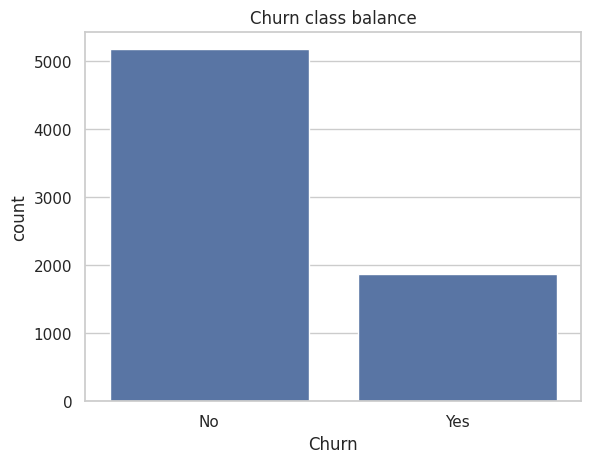

In [13]:
sns.countplot(data=teldf, x='Churn')
plt.title('Churn class balance')
plt.show()

In [14]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Summary stats by churn
summary = teldf.groupby('Churn')[num_cols].agg(['mean', 'median', 'std'])
summary

tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                         
              mean    median          std  
Churn                                      
No     2549.911442  1679.525  2329.954215  
Yes    1531.796094   703.550  1890.822994

***
### Need to preprocess data for both ML training and predicting

In [15]:
X = teldf.drop(columns = ["Churn","ChurnBinary","customerID"])
y = teldf["ChurnBinary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [16]:
print("Train shape:", X_train.shape, "\nTest shape:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4),"\nTest churn rate:", round(y_test.mean(), 4))

Train shape: (5634, 19) 
Test shape: (1409, 19)
Train churn rate: 0.2654 
Test churn rate: 0.2654


In [17]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
        ])

preprocessor.fit(X_train) # learns means, stds, and categorical vocabularies
X_train_numeric = preprocessor.transform(X_train)
X_test_numeric = preprocessor.transform(X_test)

/tmp/ipykernel_203/3956922025.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


### Baseline logistic regression:

In [18]:
logreg = LogisticRegression(max_iter = 2000)
logreg.fit(X_train_numeric, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
lr_prob = logreg.predict_proba(X_test_numeric)[:,1]
lr_pred = (lr_prob >= 0.5).astype(int)

In [20]:
### Prediction metrics:
print("Logistic Regression")
print("AUC      :", round(roc_auc_score(y_test, lr_prob), 4))
print("Accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("Precision:", round(precision_score(y_test, lr_pred), 4))
print("Recall   :", round(recall_score(y_test, lr_pred), 4))
print("F1       :", round(f1_score(y_test, lr_pred), 4))

Logistic Regression
AUC      : 0.8331
Accuracy : 0.7956
Precision: 0.6319
Recall   : 0.5508
F1       : 0.5886


### Now implement gradient boosting models for logistic regression:

In [21]:
# Now you have pure numeric matrices you can hand to XGBoost directly
xgb = XGBClassifier(n_estimators = 400, max_depth = 4, eval_metric = 'logloss')
xgb.fit(X_train_numeric, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [22]:
xgb_prob = xgb.predict_proba(X_test_numeric)[:,1]
xgb_pred = (xgb_prob >= 0.5).astype(int)

In [23]:
print("XGBoost")
print("AUC      :", round(roc_auc_score(y_test, xgb_prob), 4))
print("Accuracy :", round(accuracy_score(y_test, xgb_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_pred), 4))
print("Recall   :", round(recall_score(y_test, xgb_pred), 4))
print("F1       :", round(f1_score(y_test, xgb_pred), 4))

XGBoost
AUC      : 0.8112
Accuracy : 0.7729
Precision: 0.5849
Recall   : 0.4973
F1       : 0.5376


***
### Now we want to generate confidence intervals along with predictions, where the natural tool to use is a Bayesian Neural Network:

In [34]:
# Need to tensor-ize the training data for the neural network input
X_train_t = torch.tensor(np.asarray(X_train_numeric), dtype = torch.float32)
X_test_t = torch.tensor(np.asarray(X_test_numeric), dtype = torch.float32)
y_train_t = torch.tensor(np.asarray(y_train), dtype = torch.float32).unsqueeze(1)
y_test_t = torch.tensor(np.asarray(y_test), dtype = torch.float32).unsqueeze(1)

train_data = TensorDataset(X_train_t, y_train_t)

In [35]:
train_loader = DataLoader(train_data, batch_size = 256, shuffle = True)

In [47]:
print(X_train_t.shape, X_test_t.shape, y_train_t.shape, y_test_t.shape) 

torch.Size([5634, 45]) torch.Size([1409, 45]) torch.Size([5634, 1]) torch.Size([1409, 1])


In [49]:
class MCDropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden=64, p_drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden, 1))
    
    def forward(self, x):
        return self.net(x)  

In [50]:
# Number of features
n_features = X_train_t.shape[1]

In [52]:
# Instantiate the neural network
nn_model = MCDropoutMLP(input_dim = n_features)

In [53]:
# Setup Binary Cross Entropy loss function
loss_fn = nn.BCEWithLogitsLoss()